#  Analyse et Nettoyage des Données Douanières (GAINDE 2000 / ORBUS)

Ce notebook présente les étapes de nettoyage, de consolidation et d'analyse exploratoire (EDA) sur les données douanières. Le dataset comprend trois grandes catégories de fichiers :
1. **Les Dossiers (`ENTETE_DOSSIER.csv`)** : En-têtes administratifs contenant les importateurs, banques, assurances, et modes de transport.
2. **Les Factures (`FACTURE.csv`)** : En-têtes commerciaux avec les devises, montants globaux, exportateurs et pays.
3. **Les Articles (`Articles1.csv`, `Articles2.csv`, `ARTICLES_PARTIE1.csv`, `ARTICLES_PARTIE2.csv`)** : Les lignes individuelles de chaque facture avec les désignations, quantités et valeurs unitaires.

## 1. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")

## 2. Chargement des Fichiers Nettoyés

Les fichiers d'origine ont été consolidés et nettoyés via des scripts automatiques (suppression des BOM, conversion des virgules en points pour les colonnes numériques, et attribution de noms de colonnes explicites pour les fichiers qui en étaient dépourvus).

In [2]:
print("Chargement des fichiers...")
articles = pd.read_csv('articles_clean_all.csv', low_memory=False)
factures = pd.read_csv('factures_clean.csv', low_memory=False)
dossiers = pd.read_csv('entete_dossier_clean.csv', low_memory=False)

print(f"Articles : {articles.shape[0]:,} lignes, {articles.shape[1]} colonnes")
print(f"Factures : {factures.shape[0]:,} lignes, {factures.shape[1]} colonnes")
print(f"Dossiers : {dossiers.shape[0]:,} lignes, {dossiers.shape[1]} colonnes")

Chargement des fichiers...
Articles : 1,201,958 lignes, 28 colonnes
Factures : 301,230 lignes, 57 colonnes
Dossiers : 350,791 lignes, 80 colonnes


## 3. Aperçu Général des Jeux de Données

In [3]:
print("--- Aperçu des Articles ---")
display(articles.head(3))

print("\n--- Aperçu des Factures ---")
display(factures[['IDTPSFACTURE', 'NUMERODOSSIERTPS', 'DEVISE', 'NOM_EXPORTATEUR', 'VALEUR_TOTAL_CFA']].head(3))

print("\n--- Aperçu des Dossiers ---")
display(dossiers[['NUMERODOSSIERTPS', 'TYPE_OPERATION', 'DATE_CREATION', 'NOM_IMPORTATEUR', 'MODE_TRANSPORT']].head(3))

--- Aperçu des Articles ---


,IDTPSFACTURE,NUMEROTARIFDOUANE,NUMERODOSSIERTPS,DESIGNATIONCOMMERCIALE,PAYSPROVENANCE,PAYSORIGINE,PAYSDESTINATION,UNITEMESURE,QUANTITEMESURE,POIDSNET,POIDSBRUT,VALEURUNITAIRECFA,VALEURCFA,VALEURUNITAIREDEVISE,VALEURDEVISE,VALEURUNITAIREFOBCFA,VALEURFOBCFA,VALEURUNITAIREFOBDEVISE,VALEURFOBDEVISE,ORDRE,P_UNITAIRE,REGION_ORIGINE,median,std,count,Z_SCORE,SUSPECT_Z,ANOMALY_IF
0,2226379.0,8443990000,2518781.0,toner cyan c454 c554 c258 c308 c368tn512c,France,Taiwan,Sénégal,U,4.0,NaN,NaN,102066.0,102066.0,155.6,155.6,0.0,102066.0,0.0,155.6,50.0,25516.500000,Autres,32141.500000,1.026121e+08,2879.0,-0.000065,False,False
1,3049102.0,5608190000,3491058.0,NETS AND NETTING -MOSQUITO DOMETENT,Belgique,Chine,Sénégal,BOX,34.0,NaN,NaN,NaN,2746049.0,0.0,4896.0,0.0,2746049.0,0.0,4896.0,1.0,80766.147059,Asie,22958.000000,5.155018e+07,105.0,0.001121,False,False
2,2191262.0,3304990000,2479632.0,topicrem uh corps lait tb200ml,France,France,Sénégal,U,70.0,NaN,NaN,NaN,160250.0,0.0,244.3,0.0,160250.0,0.0,244.3,16.0,2289.285714,Europe,2538.527778,NaN,12571.0,NaN,False,False



--- Aperçu des Factures ---


,IDTPSFACTURE,NUMERODOSSIERTPS,DEVISE,NOM_EXPORTATEUR,VALEUR_TOTAL_CFA
0,2380116,2687099,CFA,SONIT PECHE,11250000.0
1,2202762,2492779,EUR,JA DELMAS,2564824.0
2,2087556,2357235,EUR,SNETOR,27195977.0



--- Aperçu des Dossiers ---


,NUMERODOSSIERTPS,TYPE_OPERATION,DATE_CREATION,NOM_IMPORTATEUR,MODE_TRANSPORT
0,2622933,Exportation,2021-09-24 12:10:26.533,GIE SANTE YALLA,Mer
1,2352920,Importation,2020-01-28 10:22:10.260,Sofiex,Mer
2,2446062,Transit,2020-08-18 15:53:16.223,LOUIS DREYFUS COMMODITIES SENEGAL (LDC SENEGAL),Mer


## 4. Analyse Exploratoire & Statistiques Métiers

### A. Volume Financier Total
Calculons la valeur cumulée totale transitant par le système douanier en CFA.

In [4]:
val_fac_trillions = factures['VALEUR_TOTAL_CFA'].sum() / 1e12
val_art_trillions = articles['VALEURCFA'].sum() / 1e12

print(f"Valeur totale cumulée dans les en-têtes de factures : {val_fac_trillions:.3f} Trillions CFA (Milliers de Milliards)")
print(f"Valeur totale cumulée dans les lignes d'articles : {val_art_trillions:.3f} Trillions CFA (Milliers de Milliards)")

Valeur totale cumulée dans les en-têtes de factures : 29.949 Trillions CFA (Milliers de Milliards)
Valeur totale cumulée dans les lignes d'articles : 35.325 Trillions CFA (Milliers de Milliards)


### B. Top 10 des Pays d'Origine par valeur des Marchandises

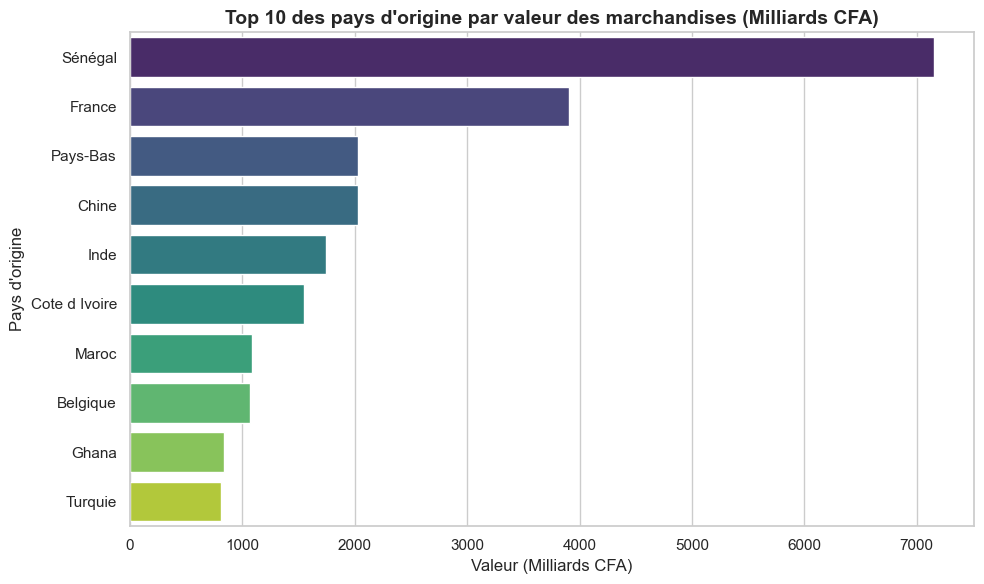

In [5]:
country_value = articles.groupby('PAYSORIGINE')['VALEURCFA'].sum().reset_index()
top_countries = country_value.sort_values('VALEURCFA', ascending=False).head(10)
top_countries['VALEUR_MILLIARDS_CFA'] = top_countries['VALEURCFA'] / 1e9

plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, x='VALEUR_MILLIARDS_CFA', y='PAYSORIGINE', palette='viridis')
plt.title("Top 10 des pays d'origine par valeur des marchandises (Milliards CFA)", fontsize=14, fontweight='bold')
plt.xlabel("Valeur (Milliards CFA)")
plt.ylabel("Pays d'origine")
plt.tight_layout()
plt.show()

### C. Répartition par Mode de Transport
Regardons comment les dossiers se répartissent selon le mode d'acheminement des marchandises.

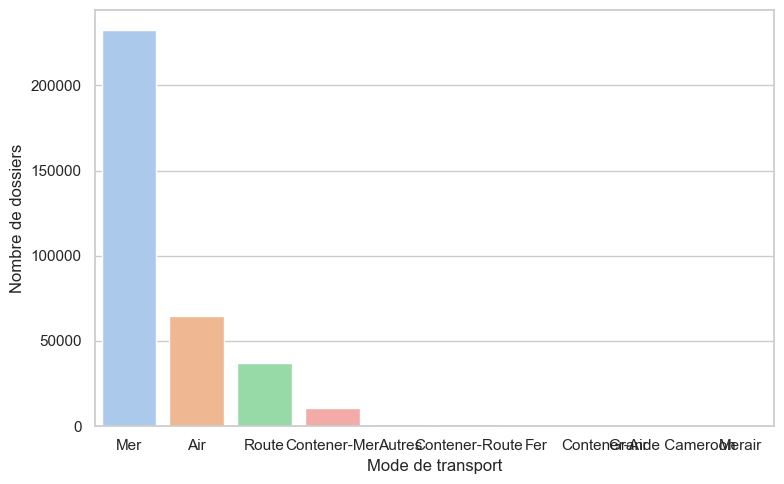

In [6]:
transport_stats = dossiers.groupby('MODE_TRANSPORT').size().reset_index(name='Nombre de dossiers')
transport_stats = transport_stats.sort_values('Nombre de dossiers', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=transport_stats, x='MODE_TRANSPORT', y='Nombre de dossiers', palette='pastel')
plt.title("", fontsize=14, fontweight='bold')
plt.xlabel("Mode de transport")
plt.ylabel("Nombre de dossiers")
plt.tight_layout()
plt.show()

### D. Top 10 des Devises les Plus Utilisées

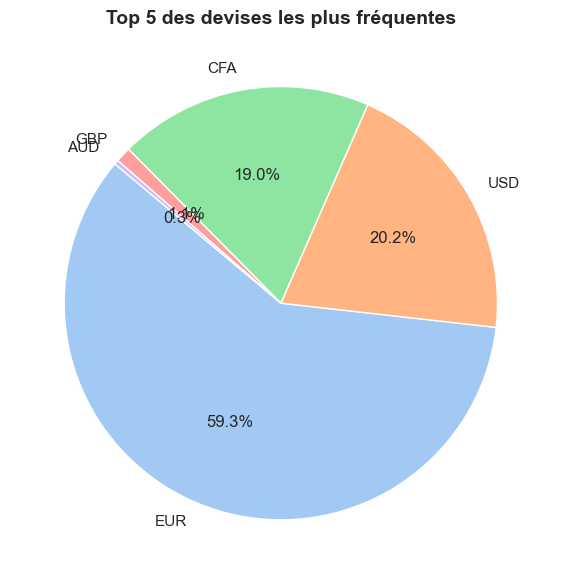

In [7]:
currency_stats = factures.groupby('DEVISE').size().reset_index(name='Nombre de factures')
top_currencies = currency_stats.sort_values('Nombre de factures', ascending=False).head(5)

plt.figure(figsize=(6, 6))
plt.pie(top_currencies['Nombre de factures'], labels=top_currencies['DEVISE'], autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=140)
plt.title("Top 5 des devises les plus fréquentes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### E. Top 10 des Banques de Financement des Dossiers

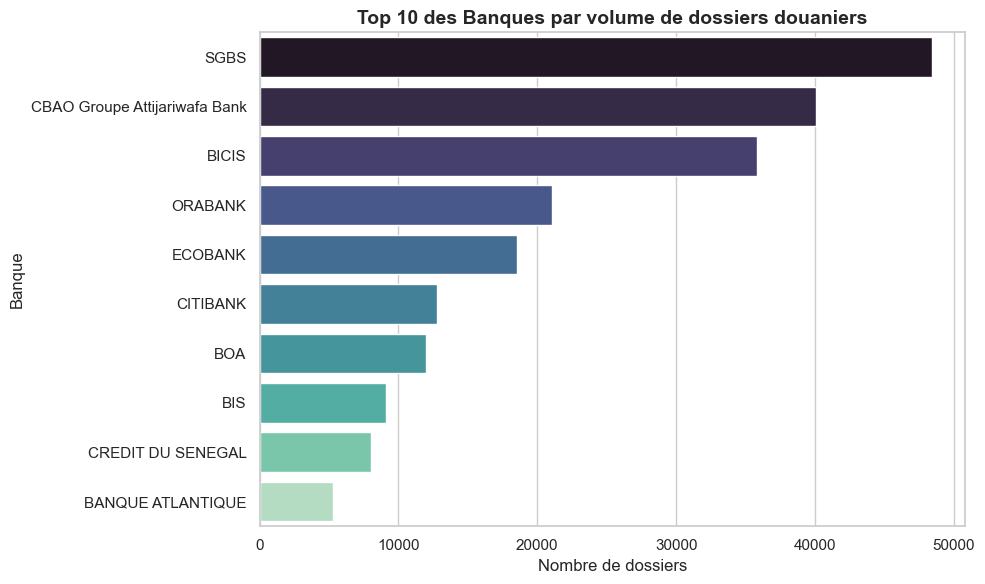

In [8]:
bank_stats = dossiers.groupby('BANQUE').size().reset_index(name='Nombre de dossiers')
top_banks = bank_stats.sort_values('Nombre de dossiers', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_banks, x='Nombre de dossiers', y='BANQUE', palette='mako')
plt.title("Top 10 des Banques par volume de dossiers douaniers", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de dossiers")
plt.ylabel("Banque")
plt.tight_layout()
plt.show()

### F. Répartition par Type d'Opération

Dans cette section, nous analysons la répartition des dossiers douaniers et de leur valeur financière selon le **Type d'Opération** :
*   **Importation** : Introduction de marchandises étrangères sur le territoire national.
*   **Exportation** : Sortie de marchandises nationales vers l'étranger.
*   **Réexportation** : Exportation de marchandises préalablement importées.
*   **Transit** : Transport de marchandises sous contrôle douanier à travers le territoire national.


Nombre de dossiers par type d'opération :
TYPE_OPERATION
Importation      253780
Exportation       75507
Réexportation     12732
Transit            8772
Name: count, dtype: int64

Valeur financière (CFA) par type d'opération :
  Exportation : 6,037,414,185,133.35 CFA
  Importation : 26,986,843,063,372.42 CFA
  Réexportation : 652,200,098,631.32 CFA
  Transit : 107,684,853,297.10 CFA


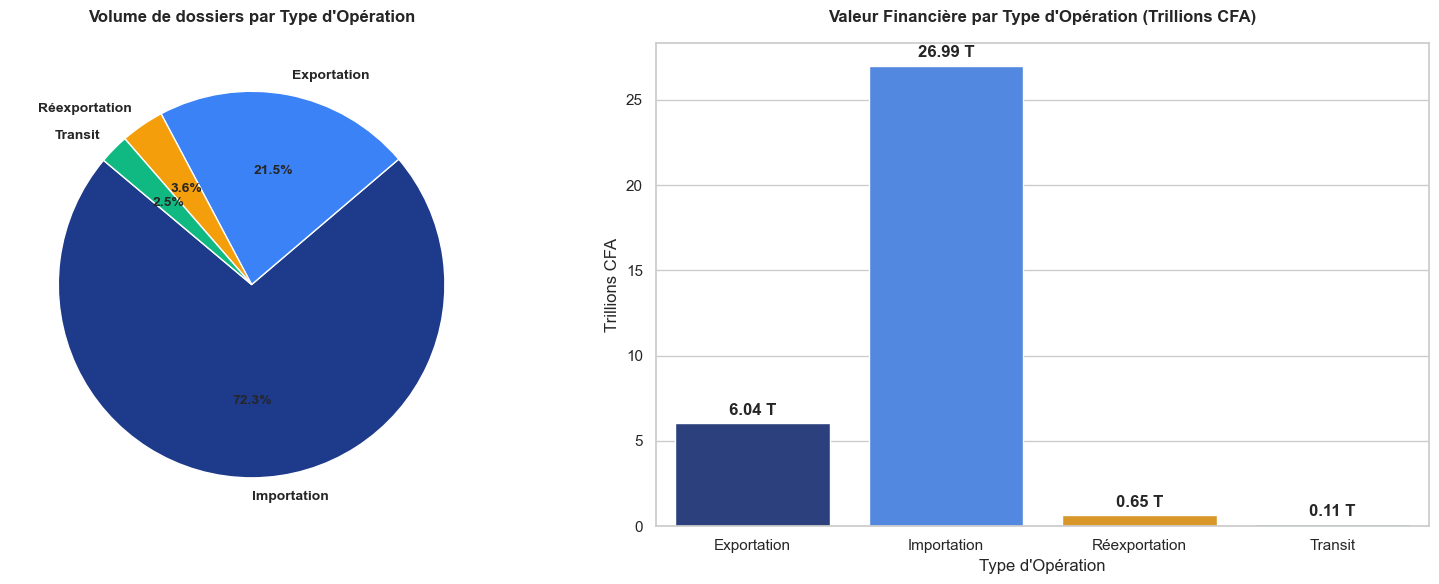

In [9]:
# Calcul et affichage de la répartition par type d'opération
op_counts = dossiers['TYPE_OPERATION'].value_counts()
print("Nombre de dossiers par type d'opération :")
print(op_counts)

# Fusionner pour obtenir les valeurs par type d'opération
df_art_dos_op = articles.merge(dossiers[['NUMERODOSSIERTPS', 'TYPE_OPERATION']], on='NUMERODOSSIERTPS', how='left')
op_vals = df_art_dos_op.groupby('TYPE_OPERATION')['VALEURCFA'].sum()
print("\nValeur financière (CFA) par type d'opération :")
for op, val in op_vals.items():
    print(f"  {op} : {val:,.2f} CFA")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Volume (Pie)
colors_op = ['#1e3a8a', '#3b82f6', '#f59e0b', '#10b981']
axes[0].pie(op_counts, labels=op_counts.index, autopct='%1.1f%%', startangle=140, colors=colors_op, textprops={'fontsize': 10, 'weight': 'bold'})
axes[0].set_title("Volume de dossiers par Type d'Opération", fontsize=12, fontweight='bold', pad=15)

# Subplot 2: Valeur (Bar)
sns.barplot(x=op_vals.index, y=op_vals.values / 1e12, ax=axes[1], palette=colors_op)
axes[1].set_title("Valeur Financière par Type d'Opération (Trillions CFA)", fontsize=12, fontweight='bold', pad=15)
axes[1].set_ylabel("Trillions CFA")
axes[1].set_xlabel("Type d'Opération")
for i, v in enumerate(op_vals.values):
    axes[1].text(i, (v / 1e12) + 0.5, f"{v/1e12:.2f} T", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Contrôles de Cohérence & Jointures

Vérifions le taux de liaison entre les tables principales.

In [10]:
art_ids = set(articles['IDTPSFACTURE'].dropna().astype(int))
fac_ids = set(factures['IDTPSFACTURE'].dropna().astype(int))
matching_ids = art_ids.intersection(fac_ids)

print(f"Taux de correspondance Factures dans les Articles : {len(matching_ids)/len(art_ids)*100:.2f}%")

fac_dossiers = set(factures['NUMERODOSSIERTPS'].dropna().astype(int))
dos_dossiers = set(dossiers['NUMERODOSSIERTPS'].dropna().astype(int))
matching_dossiers = fac_dossiers.intersection(dos_dossiers)

print(f"Taux de correspondance Dossiers dans les Factures : {len(matching_dossiers)/len(fac_dossiers)*100:.2f}%")

Taux de correspondance Factures dans les Articles : 93.58%
Taux de correspondance Dossiers dans les Factures : 100.00%


## 6. Prélude au Machine Learning : Détection d'Anomalies de Valeurs (Sous-Évaluation)

Une fraude courante en douane consiste à déclarer une marchandise avec une valeur unitaire anormalement basse pour payer moins de droits de douane.
Nous allons construire un modèle statistique de détection d'anomalies (Z-score robuste) :
1. Calculer le prix unitaire réel déclaré de chaque article (`VALEURCFA / QUANTITEMESURE`).
2. Grouper les articles par code tarifaire douanier (`NUMEROTARIFDOUANE`) et calculer le prix unitaire médian et l'écart type pour chaque type de produit.
3. Calculer un score d'écart (Z-score) pour chaque ligne. Si un article a un score très négatif, il est marqué comme suspect de sous-évaluation.

In [11]:
# 1. Filtrer les articles valides
df_ml = articles[articles['QUANTITEMESURE'] > 0].copy()
df_ml['PRIX_UNITAIRE_DECLARE'] = df_ml['VALEURCFA'] / df_ml['QUANTITEMESURE']

# 2. Calculer les statistiques de référence par Code Tarifaire
tariff_stats = df_ml.groupby('NUMEROTARIFDOUANE')['PRIX_UNITAIRE_DECLARE'].agg(['median', 'std', 'count']).reset_index()
tariff_stats.columns = ['NUMEROTARIFDOUANE', 'PRIX_MEDIAN_TARIF', 'PRIX_STD_TARIF', 'NB_ARTICLES_TARIF']

# Fusionner avec nos données
df_ml = pd.merge(df_ml, tariff_stats, on='NUMEROTARIFDOUANE', how='inner')

# 3. Calculer le score de déviation (Z-Score robuste)
# On évite la division par zéro en ajoutant un epsilon ou en remplaçant std nul par 1
df_ml['PRIX_STD_TARIF'] = df_ml['PRIX_STD_TARIF'].replace(0, 1).fillna(1)
df_ml['Z_SCORE_PRIX'] = (df_ml['PRIX_UNITAIRE_DECLARE'] - df_ml['PRIX_MEDIAN_TARIF']) / df_ml['PRIX_STD_TARIF']

# 4. Marquer les anomalies (Z-score < -1.5 et sur des tarifs avec suffisamment d'historique)
df_ml['SUSPECT_SOUS_EVALUATION'] = (df_ml['Z_SCORE_PRIX'] < -1.5) & (df_ml['NB_ARTICLES_TARIF'] >= 10)

anomalies_detectees = df_ml[df_ml['SUSPECT_SOUS_EVALUATION'] == True]
print(f"Nombre d'articles suspects détectés par le modèle : {len(anomalies_detectees):,} ({len(anomalies_detectees)/len(df_ml)*100:.2f}% du total)")
display(anomalies_detectees[['NUMEROTARIFDOUANE', 'DESIGNATIONCOMMERCIALE', 'PAYSORIGINE', 'QUANTITEMESURE', 'PRIX_UNITAIRE_DECLARE', 'PRIX_MEDIAN_TARIF', 'Z_SCORE_PRIX']].head(10))

Nombre d'articles suspects détectés par le modèle : 1,555 (0.13% du total)


,NUMEROTARIFDOUANE,DESIGNATIONCOMMERCIALE,PAYSORIGINE,QUANTITEMESURE,PRIX_UNITAIRE_DECLARE,PRIX_MEDIAN_TARIF,Z_SCORE_PRIX
335548,3902300000,MOPLEN EP 548U POLYPROPYLENE,Arabie Saoudite,148500.0,1200.401306,655956.989899,-1.654669
335549,3902300000,BJ368MO BOROUGE BAG POLYPROPYLENE COPOLYMER,Emirats Arabes Unis,24750.0,606.104242,655956.989899,-1.656170
335550,3902300000,BJ368MO BOROUGE BAG PROPYLENE COPOLYMER,Autriche,49500.0,632.998485,655956.989899,-1.656103
335551,3902300000,POLYPROPYLENE IMPACT COPOLYMER,Arabie Saoudite,49500.0,570.682586,655956.989899,-1.656260
335553,3902300000,MOPLEN EP 548Q POLYPROPYLENE,Arabie Saoudite,85000.0,1023.292918,655956.989899,-1.655116
335562,3902300000,BOROUGE BAG POLYPROPYLENE COPOLYMER,Emirats Arabes Unis,24750.0,921.619556,655956.989899,-1.655373
335567,3902300000,BOROUGE BAG POLYPROPYLENE COPOLYMER,Emirats Arabes Unis,49500.0,583.801717,655956.989899,-1.656227
335569,3902300000,PLASTIQUE PP HOMO RAFFIA,Arabie Saoudite,49500.0,945.489859,655956.989899,-1.655313
335571,3902300000,PP COPOLYMER,Thailande,51750.0,1029.852483,655956.989899,-1.655100
335572,3902300000,ESD PP COPO 245-DUM,Arabie Saoudite,49500.0,823.226020,655956.989899,-1.655622


## 7. Prélude au Machine Learning : Prédiction Temporelle des Flux (Forecasting)

Pour prévoir les recettes douanières ou les flux logistiques futurs, nous devons transformer nos données transactionnelles en données de séries temporelles régulières (quotidiennes ou hebdomadaires).

In [12]:
# 1. Préparer les données temporelles de dossiers
df_time = dossiers[['DATE_CREATION']].copy()
df_time['DATE_CREATION'] = pd.to_datetime(df_time['DATE_CREATION'], errors='coerce')
df_time = df_time.dropna()

# 2. Agréger par jour pour obtenir la série temporelle
daily_series = df_time.groupby(df_time['DATE_CREATION'].dt.date).size().reset_index(name='VOLUME_DOSSIERS')
daily_series.columns = ['DATE', 'VOLUME_DOSSIERS']
daily_series = daily_series.set_index('DATE')
daily_series.index = pd.to_datetime(daily_series.index)

# Remplir les dates manquantes avec des zéros
daily_series = daily_series.asfreq('D', fill_value=0)

print("Série temporelle quotidienne générée :")
display(daily_series.head())

# 3. Créer des caractéristiques d'historique (Lag features)
# Pour que le ML puisse prédire J, il doit connaître J-1, J-7, etc.
for lag in [1, 2, 7, 14]:
    daily_series[f'LAG_{lag}'] = daily_series['VOLUME_DOSSIERS'].shift(lag)

# Moyennes mobiles pour lisser la tendance
daily_series['MOYENNE_MOBILE_7J'] = daily_series['VOLUME_DOSSIERS'].rolling(window=7).mean()

display(daily_series.dropna().head(10))

Série temporelle quotidienne générée :


,VOLUME_DOSSIERS
DATE,
2020-01-02,779
2020-01-03,614
2020-01-04,27
2020-01-05,5
2020-01-06,734


,VOLUME_DOSSIERS,LAG_1,LAG_2,LAG_7,LAG_14,MOYENNE_MOBILE_7J
DATE,,,,,,
2020-01-16,818,695.0,805.0,717.0,779.0,565.857143
2020-01-17,618,818.0,695.0,746.0,614.0,547.571429
2020-01-18,33,618.0,818.0,35.0,27.0,547.285714
2020-01-19,11,33.0,618.0,5.0,5.0,548.142857
2020-01-20,855,11.0,33.0,857.0,734.0,547.857143
2020-01-21,808,855.0,11.0,805.0,740.0,548.285714
2020-01-22,756,808.0,855.0,695.0,746.0,557.000000
2020-01-23,681,756.0,808.0,818.0,717.0,537.428571
2020-01-24,659,681.0,756.0,618.0,746.0,543.285714


## 8. Analyses Avancées & Segmentation Métier

Dans cette section, nous approfondissons l'analyse avec :
1. Une segmentation non-supervisée (K-Means) des importateurs.
2. Une analyse de Pareto (80/20) sur la concentration de la valeur des échanges.
3. Une analyse temporelle de saisonnalité fine par jour de la semaine, mois et trimestre.


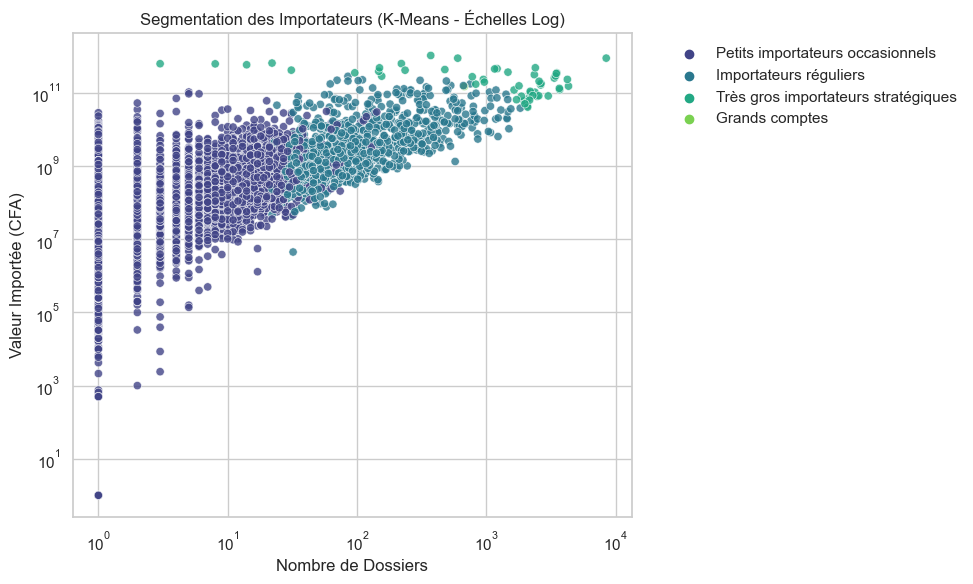

In [13]:
# A. Segmentation K-Means des importateurs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Lecture des données nettoyées et fusionnées
df_articles = pd.read_csv('articles_clean_all.csv', low_memory=False)
df_dossiers = pd.read_csv('entete_dossier_clean.csv', low_memory=False)

# Merging to get NOM_IMPORTATEUR
df_dossiers['DATE_DT'] = pd.to_datetime(df_dossiers['DATE_CREATION'], errors='coerce')
df_art_dos = df_articles.merge(df_dossiers[['NUMERODOSSIERTPS', 'MODE_TRANSPORT', 'TYPE_OPERATION', 'NOM_IMPORTATEUR', 'DATE_DT']], on='NUMERODOSSIERTPS', how='left')

# Importer features
importer_features = df_art_dos.groupby('NOM_IMPORTATEUR').agg(
    dossier_count=('NUMERODOSSIERTPS', 'nunique'),
    total_value=('VALEURCFA', 'sum'),
    total_qty=('QUANTITEMESURE', 'sum'),
    active_weeks=('DATE_DT', lambda x: x.dt.isocalendar().week.nunique() if not x.isna().all() else 1)
).reset_index().dropna()

# Scaling and KMeans
scaler = StandardScaler()
scaled_feats = scaler.fit_transform(importer_features[['dossier_count', 'total_value', 'total_qty', 'active_weeks']])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
importer_features['cluster'] = kmeans.fit_predict(scaled_feats)

# Relabel dynamically by median total value
cluster_means = importer_features.groupby('cluster')['total_value'].median().sort_values().index
cluster_labels = {
    cluster_means[0]: 'Petits importateurs occasionnels',
    cluster_means[1]: 'Importateurs réguliers',
    cluster_means[2]: 'Grands comptes',
    cluster_means[3]: 'Très gros importateurs stratégiques'
}
importer_features['segment'] = importer_features['cluster'].map(cluster_labels)

# Visualisation des clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=importer_features, 
    x='dossier_count', 
    y='total_value', 
    hue='segment', 
    palette='viridis', 
    alpha=0.8
)
plt.yscale('log')
plt.xscale('log')
plt.title("Segmentation des Importateurs (K-Means - Échelles Log)")
plt.xlabel("Nombre de Dossiers")
plt.ylabel("Valeur Importée (CFA)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Pareto Importateurs : Top 20% des importateurs représentent 98.54% de la valeur cumulée.
Pareto Marchandises : Top 20% des produits représentent 97.50% du montant total.


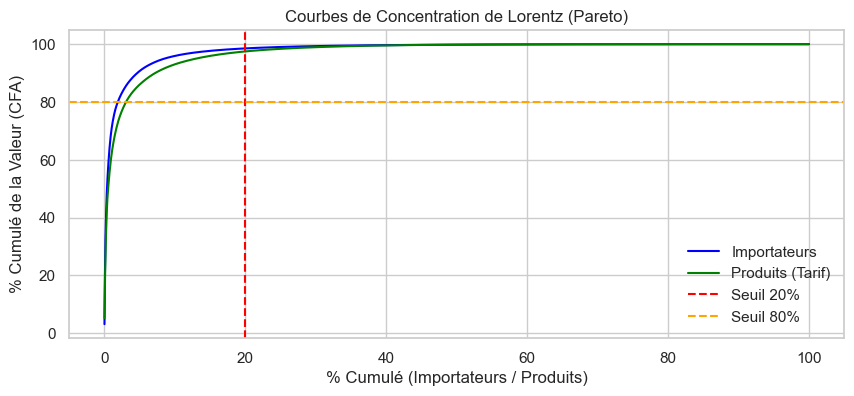

In [14]:
# B. Analyse Pareto 80/20
# Concentration chez les importateurs
importer_vals = df_art_dos.groupby('NOM_IMPORTATEUR')['VALEURCFA'].sum().sort_values(ascending=False)
cum_importer_val = importer_vals.cumsum() / importer_vals.sum()
top_20pct_count = int(np.ceil(0.20 * len(importer_vals)))
importer_pareto_val = cum_importer_val.iloc[min(top_20pct_count, len(cum_importer_val)-1)] * 100

print(f"Pareto Importateurs : Top 20% des importateurs représentent {importer_pareto_val:.2f}% de la valeur cumulée.")

# Concentration sur les marchandises
product_vals = df_articles.groupby('NUMEROTARIFDOUANE')['VALEURCFA'].sum().sort_values(ascending=False)
cum_product_val = product_vals.cumsum() / product_vals.sum()
top_20pct_prod_count = int(np.ceil(0.20 * len(product_vals)))
product_pareto_val = cum_product_val.iloc[min(top_20pct_prod_count, len(cum_product_val)-1)] * 100

print(f"Pareto Marchandises : Top 20% des produits représentent {product_pareto_val:.2f}% du montant total.")

# Plot Pareto
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(cum_importer_val)) / len(cum_importer_val) * 100, cum_importer_val * 100, label="Importateurs", color='blue')
plt.plot(np.arange(len(cum_product_val)) / len(cum_product_val) * 100, cum_product_val * 100, label="Produits (Tarif)", color='green')
plt.axvline(20, color='red', linestyle='--', label="Seuil 20%")
plt.axhline(80, color='orange', linestyle='--', label="Seuil 80%")
plt.title("Courbes de Concentration de Lorentz (Pareto)")
plt.xlabel("% Cumulé (Importateurs / Produits)")
plt.ylabel("% Cumulé de la Valeur (CFA)")
plt.legend()
plt.grid(True)
plt.show()


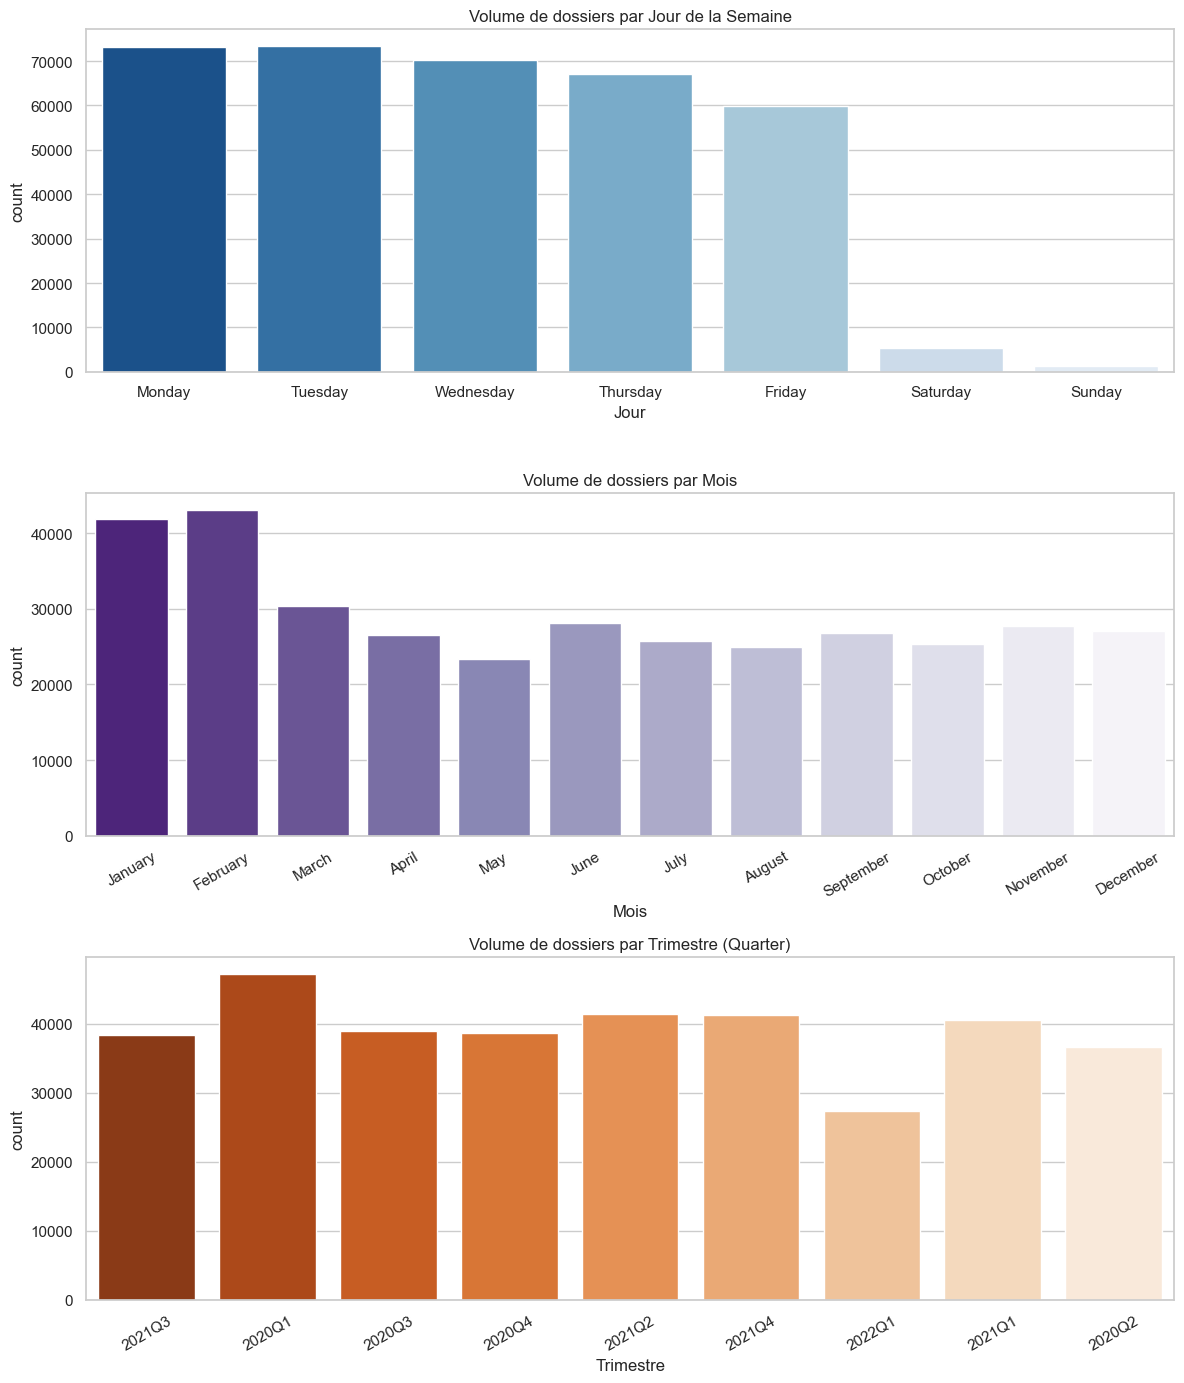

In [15]:
# C. Analyse Temporelle Décomposée
df_dossiers['DAY_OF_WEEK'] = df_dossiers['DATE_DT'].dt.day_name()
df_dossiers['MONTH'] = df_dossiers['DATE_DT'].dt.month_name()
df_dossiers['QUARTER'] = df_dossiers['DATE_DT'].dt.to_period('Q').astype(str)

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# 1. Day of Week
sns.countplot(data=df_dossiers, x='DAY_OF_WEEK', order=dow_order, ax=axes[0], palette='Blues_r')
axes[0].set_title("Volume de dossiers par Jour de la Semaine")
axes[0].set_xlabel("Jour")

# 2. Month
sns.countplot(data=df_dossiers, x='MONTH', order=month_order, ax=axes[1], palette='Purples_r')
axes[1].set_title("Volume de dossiers par Mois")
axes[1].set_xlabel("Mois")
axes[1].tick_params(axis='x', rotation=30)

# 3. Quarter
sns.countplot(data=df_dossiers, x='QUARTER', ax=axes[2], palette='Oranges_r')
axes[2].set_title("Volume de dossiers par Trimestre (Quarter)")
axes[2].set_xlabel("Trimestre")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 9. Analyse et Score de Risque Douanier

Nous mettons en place un modèle de notation (Score de Risque sur 100) combinant plusieurs critères :
1. Détection de sous-évaluation (Z-score unitaire suspect) : **+40 points**
2. Valeur très atypique (dossier dans le Top 10% par valeur) : **+20 points**
3. Importateur récent/occasionnel ($\le 3$ déclarations) : **+15 points**
4. Provenance d'un pays à risque (taux de fraude historique élevé) : **+15 points**
5. Quantité inhabituelle (Top 5% pour le code tarifaire) : **+10 points**

Les dossiers sont ensuite classés en :
- **Faible risque** (Score < 30)
- **Moyen risque** (30 $\le$ Score < 60)
- **Haut risque** (Score $\ge$ 60)


Répartition des dossiers par classe de risque douanier :
RISK_CLASS
Faible risque    337008
Moyen risque      13507
Haut risque         276
Name: count, dtype: int64


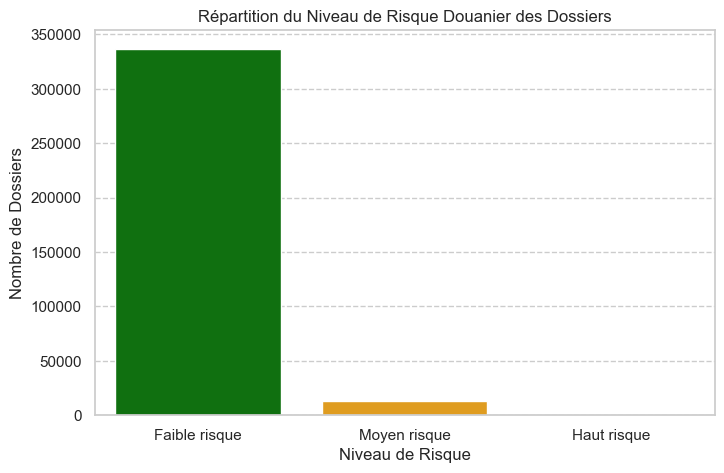

In [16]:
# Calcul du Score de Risque sur les dossiers
# Les règles ont été appliquées et sauvées dans le fichier dossiers
print("Répartition des dossiers par classe de risque douanier :")
print(df_dossiers['RISK_CLASS'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df_dossiers, x='RISK_CLASS', palette={'Faible risque': 'green', 'Moyen risque': 'orange', 'Haut risque': 'red'})
plt.title("Répartition du Niveau de Risque Douanier des Dossiers")
plt.xlabel("Niveau de Risque")
plt.ylabel("Nombre de Dossiers")
plt.grid(axis='y', linestyle='--')
plt.show()


## 10. Modélisation de la Fraude et Prédiction Temporelle

Nous comparons ici :
- Le modèle métier (Z-score robuste unitaire) avec un modèle d'IA non supervisé (**Isolation Forest**).
- Quatre modèles de prévision de la série temporelle journalière : **Moyenne Mobile (Baseline)**, **Régression Linéaire**, **Random Forest**, et **Gradient Boosting Regressor**.


In [17]:
# A. Comparaison Fraude : Z-score vs Isolation Forest
from sklearn.ensemble import IsolationForest

# Isolation Forest sur les données physiques et financières
features_if = df_articles[['VALEURCFA', 'QUANTITEMESURE', 'POIDSNET', 'POIDSBRUT']].copy().fillna(0)
iforest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
df_articles['ANOMALY_IF'] = iforest.fit_predict(features_if) == -1

# Print comparison
print(f"Articles anomalies signalées par Isolation Forest: {df_articles['ANOMALY_IF'].sum():,}")
# Le Z-score a détecté 1555 anomalies (Z < -1.5 avec historique suffisant)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Articles anomalies signalées par Isolation Forest: 12,018


Moyenne Mobile (Baseline) -> MAE: 336.01, RMSE: 382.29, MAPE: 1479.30%
Linear Regression -> MAE: 160.47, RMSE: 234.38, MAPE: 168.26%
Random Forest -> MAE: 115.75, RMSE: 195.36, MAPE: 141.33%
Gradient Boosting -> MAE: 116.98, RMSE: 194.91, MAPE: 151.80%


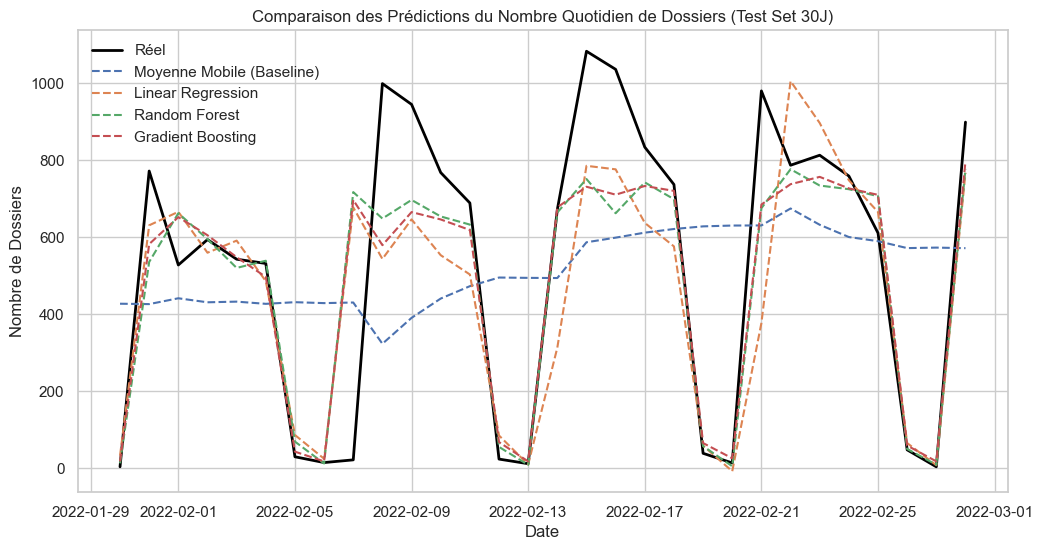

In [18]:
# B. Forecasting des Flux Douaniers (Volume Journalier)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Agrégation journalière
daily_series = df_dossiers.groupby(df_dossiers['DATE_DT'].dt.date).size().reset_index(name='y')
daily_series.columns = ['ds', 'y']
daily_series = daily_series.sort_values(by='ds')

# Lag features
for lag in [1, 2, 7, 14]:
    daily_series[f'LAG_{lag}'] = daily_series['y'].shift(lag)
daily_series['MOYENNE_MOBILE_7J'] = daily_series['y'].shift(1).rolling(7).mean()

daily_series = daily_series.dropna().reset_index(drop=True)

# Train-Test Split (les 30 derniers jours en test)
train_df = daily_series.iloc[:-30]
test_df = daily_series.iloc[-30:]

features = ['LAG_1', 'LAG_2', 'LAG_7', 'LAG_14', 'MOYENNE_MOBILE_7J']
X_train, y_train = train_df[features], train_df['y']
X_test, y_test = test_df[features], test_df['y']

# Models training
models = {
    'Moyenne Mobile (Baseline)': X_test['MOYENNE_MOBILE_7J'],
    'Linear Regression': LinearRegression().fit(X_train, y_train).predict(X_test),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train).predict(X_test),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42).fit(X_train, y_train).predict(X_test)
}

# Evaluation
metrics = {}
for name, preds in models.items():
    mae = np.mean(np.abs(y_test - preds))
    rmse = np.sqrt(np.mean((y_test - preds) ** 2))
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    metrics[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

# Plot forecasts
plt.figure(figsize=(12, 6))
plt.plot(test_df['ds'], y_test, label='Réel', color='black', linewidth=2)
for name, preds in models.items():
    plt.plot(test_df['ds'], preds, label=name, linestyle='--')
plt.title("Comparaison des Prédictions du Nombre Quotidien de Dossiers (Test Set 30J)")
plt.xlabel("Date")
plt.ylabel("Nombre de Dossiers")
plt.legend()
plt.grid(True)
plt.show()
